In [6]:
import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score, 
    confusion_matrix, roc_curve, average_precision_score, matthews_corrcoef
)

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATv2Conv
from torch_geometric.utils import to_undirected, add_self_loops

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Initializing PathoGAT Research Evaluation on: {device}")

🚀 Initializing PathoGAT Research Evaluation on: cuda


In [7]:
class GeneSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.ln1   = torch.nn.LayerNorm(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, 2)
        self.skip  = torch.nn.Linear(input_dim, hidden_dim)
        
    def forward(self, data):
        x, ei = data.x, data.edge_index
        x1 = self.conv1(x, ei) + self.skip(x)
        return self.conv2(F.elu(self.ln1(x1)), ei)

class GeneGAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=128, heads=8):
        super().__init__()
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.3)
        self.ln1   = torch.nn.LayerNorm(hidden_dim * heads)
        self.conv2 = GATv2Conv(hidden_dim * heads, 2, heads=1, concat=False)
        self.skip  = torch.nn.Linear(input_dim, hidden_dim * heads)
        
    def forward(self, data):
        x, ei = data.x, data.edge_index
        x1 = self.conv1(x, ei) + self.skip(x)
        x1 = F.elu(self.ln1(x1))
        x1 = F.dropout(x1, p=0.4, training=self.training)
        return self.conv2(x1, ei)

BASE_DATA_DIR = r"C:\mutation\data\processed"
BASE_MODEL_DIR = r"C:\mutation\models"

features_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_gene_features.csv"))
edges_df = pd.read_csv(os.path.join(BASE_DATA_DIR, "final_edge_list.csv"))
if "pathogenic" not in features_df.columns: features_df["pathogenic"] = features_df["label"]

GNN_DROP = {"GeneSymbol", "description", "label", "pathogenic_variants", "pathogenic", 
            "neighbor_pathogenic_ratio", "mutation_network_score", "rare_network_score", 
            "gene_degree", "clustering_coefficient", "pagerank", "betweenness_centrality"}
gnn_cols = [c for c in features_df.columns if c not in GNN_DROP and pd.api.types.is_numeric_dtype(features_df[c])]

y = features_df["label"].values.astype(int)
train_idx, test_idx, y_train, y_test = train_test_split(np.arange(len(y)), y, test_size=0.2, random_state=42, stratify=y)

gnn_scaler = joblib.load(os.path.join(BASE_MODEL_DIR, "feature_scaler.pkl"))
X_gnn_scaled = gnn_scaler.transform(features_df[gnn_cols].values.astype(np.float32))

genes = features_df["GeneSymbol"].tolist()
g2i = {g: i for i, g in enumerate(genes)}
valid_edges = [[g2i[r.gene1], g2i[r.gene2]] for r in edges_df.itertuples() if r.gene1 in g2i and r.gene2 in g2i]
edge_index = torch.tensor(valid_edges, dtype=torch.long).t().contiguous()
edge_index = to_undirected(edge_index)
edge_index, _ = add_self_loops(edge_index, num_nodes=len(genes))

graph_data = Data(x=torch.tensor(X_gnn_scaled, dtype=torch.float), edge_index=edge_index).to(device)

c:\mutation\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
sage_model = GeneSAGE(input_dim=len(gnn_cols)).to(device)
sage_model.load_state_dict(torch.load(os.path.join(BASE_MODEL_DIR, "gene_gnn_model.pt"), map_location=device))
sage_model.eval()

gat_model = GeneGAT(input_dim=len(gnn_cols)).to(device)
gat_model.load_state_dict(torch.load(os.path.join(BASE_MODEL_DIR, "gene_gat_model.pt"), map_location=device))
gat_model.eval()

with torch.no_grad():
    sage_probs = torch.softmax(sage_model(graph_data), dim=1)[:, 1].cpu().numpy()[test_idx]
    gat_probs = torch.softmax(gat_model(graph_data), dim=1)[:, 1].cpu().numpy()[test_idx]

ensemble_probs = (sage_probs + gat_probs) / 2.0

In [12]:
metrics_data = []
roc_data = {}
pr_data = {}
calib_data = {}
model_preds = {}

model_configs = [
    ("GraphSAGE", sage_probs, '#FF9800', '--', 2.5),
    ("GATv2", gat_probs, '#F44336', '--', 2.5),
    ("GNN Hybrid Ensemble", ensemble_probs, '#d32f2f', '-', 4.0)
]

for name, probs, color, style, lw in model_configs:
    # 1. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    roc_data[name] = (fpr, tpr, roc_auc)
    
    # 2. Precision-Recall Curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    pr_data[name] = (precisions, recalls, pr_auc)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    opt_thresh = thresholds[np.argmax(f1_scores)]
    preds = (probs >= opt_thresh).astype(int)
    model_preds[name] = preds
    
    # 4. Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    calib_data[name] = (prob_true, prob_pred)
    
    # 5. Save Leaderboard Metrics
    metrics_data.append({
        "Model": name,
        "ROC-AUC": round(roc_auc, 4),
        "PR-AUC (Avg Precision)": round(pr_auc, 4),
        "MCC (Matthews)": round(matthews_corrcoef(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4)
    })


C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\3545454233.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\mutation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


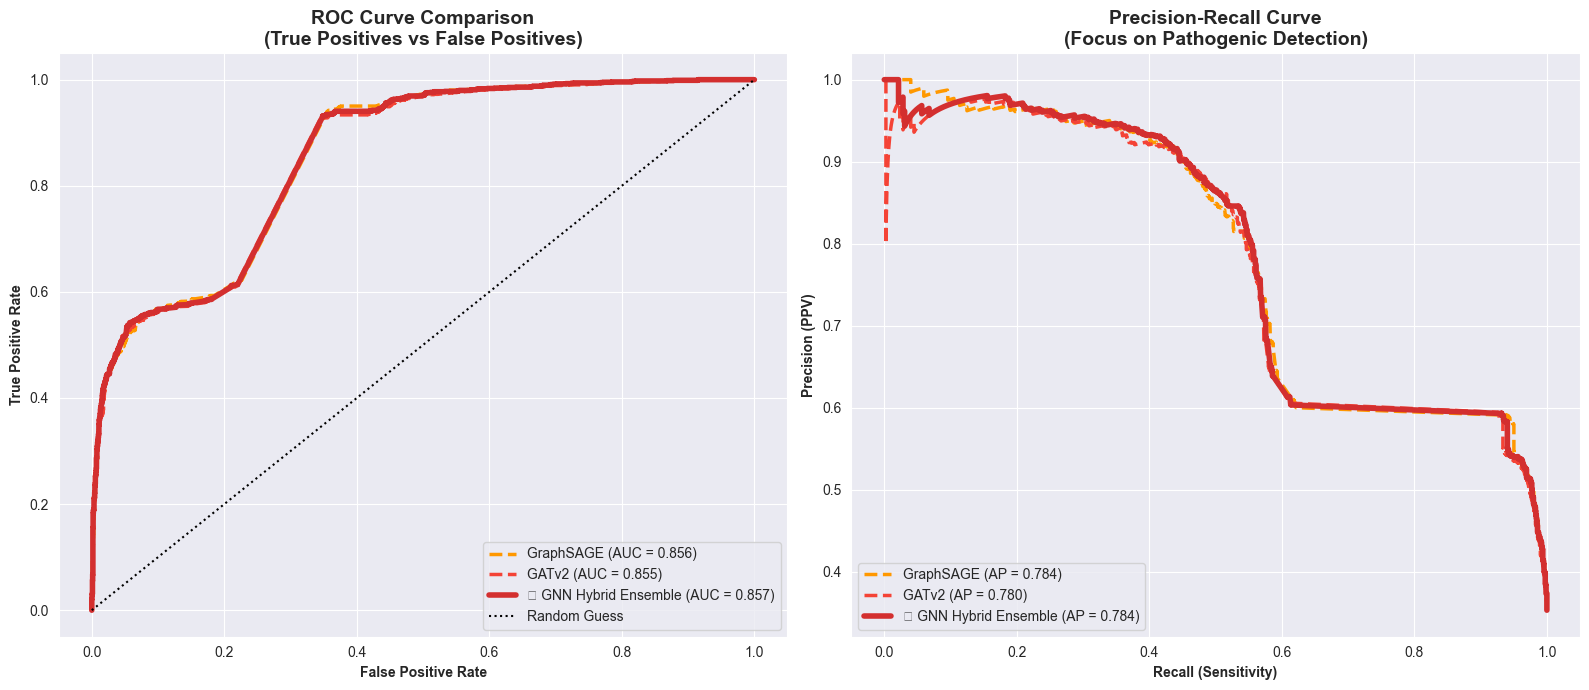

C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\3545454233.py:50: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\mutation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


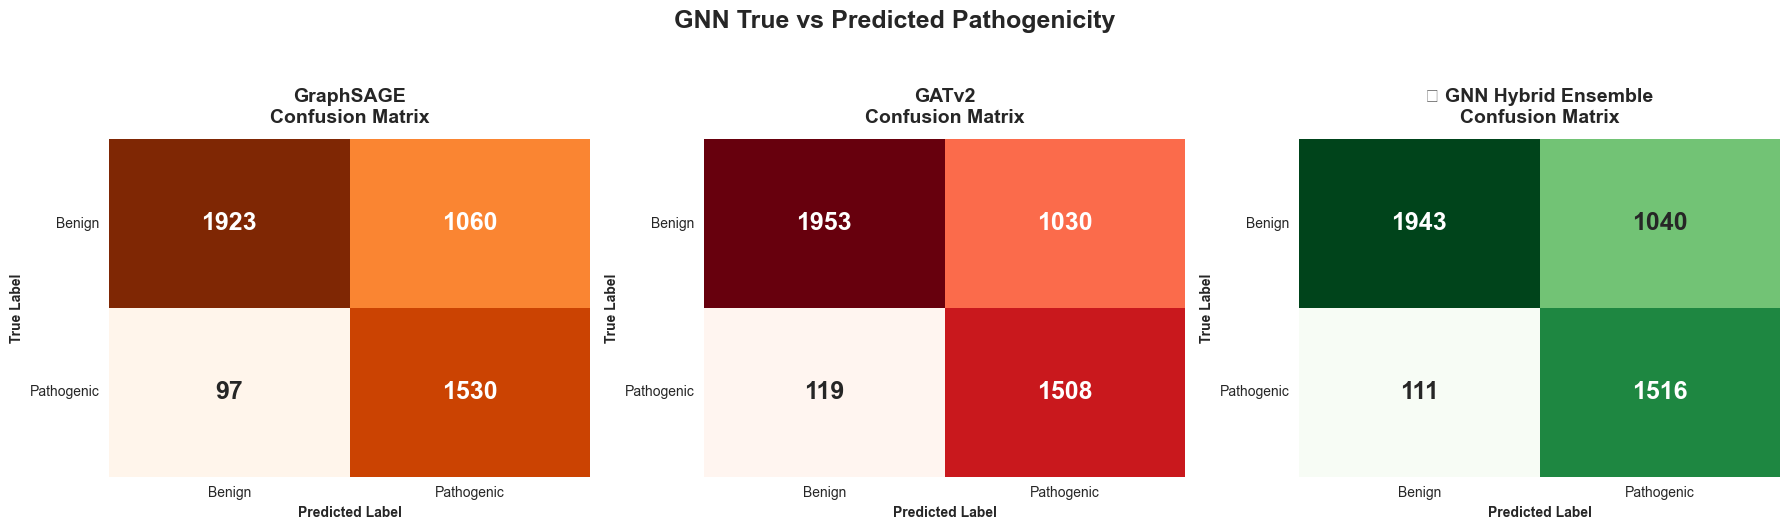

C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\3545454233.py:67: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


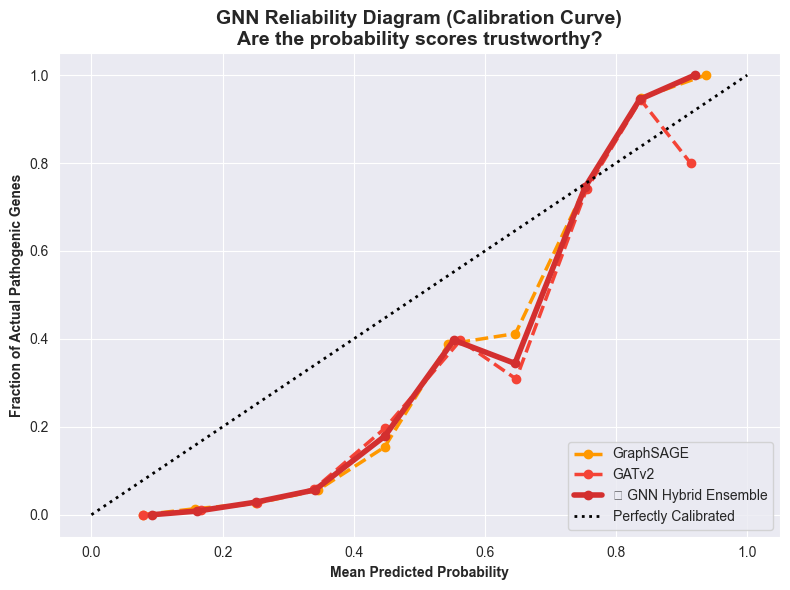


🏆 RESEARCH-GRADE GNN LEADERBOARD 🏆


,Model,ROC-AUC,PR-AUC (Avg Precision),MCC (Matthews),F1-Score
0,GraphSAGE,0.856300,0.783900,0.563500,0.725600
1,GNN Hybrid Ensemble,0.856700,0.784300,0.560700,0.724800
2,GATv2,0.854900,0.779600,0.558700,0.724100


In [13]:
sns.set_style("darkgrid")

# --- FIGURE 1: ROC & PR CURVES (1x2 GRID) ---
fig1, ax1 = plt.subplots(1, 2, figsize=(16, 7))

for name, _, color, style, lw in model_configs:
    prefix = "★ " if "Ensemble" in name else ""
    
    # Plot ROC
    fpr, tpr, roc_auc = roc_data[name]
    ax1[0].plot(fpr, tpr, color=color, linestyle=style, lw=lw, label=f'{prefix}{name} (AUC = {roc_auc:.3f})')
    
    # Plot PR Curve
    precisions, recalls, pr_auc = pr_data[name]
    ax1[1].plot(recalls, precisions, color=color, linestyle=style, lw=lw, label=f'{prefix}{name} (AP = {pr_auc:.3f})')

# Format ROC
ax1[0].plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random Guess')
ax1[0].set_title('ROC Curve Comparison\n(True Positives vs False Positives)', fontsize=14, fontweight='bold')
ax1[0].set_xlabel('False Positive Rate', fontweight='bold')
ax1[0].set_ylabel('True Positive Rate', fontweight='bold')
ax1[0].legend(loc="lower right", frameon=True)

# Format PR
ax1[1].set_title('Precision-Recall Curve\n(Focus on Pathogenic Detection)', fontsize=14, fontweight='bold')
ax1[1].set_xlabel('Recall (Sensitivity)', fontweight='bold')
ax1[1].set_ylabel('Precision (PPV)', fontweight='bold')
ax1[1].legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()

# --- FIGURE 2: 1x3 CONFUSION MATRIX GRID ---
sns.set_style("white")
fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5))
cmap_colors = ['Oranges', 'Reds', 'Greens']

for i, (name, _, _, _, _) in enumerate(model_configs):
    cm = confusion_matrix(y_test, model_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_colors[i], ax=ax2[i], cbar=False, annot_kws={"size": 18, "weight": "bold"})
    
    prefix = "★ " if "Ensemble" in name else ""
    ax2[i].set_title(f'{prefix}{name}\nConfusion Matrix', fontsize=14, fontweight='bold', pad=12)
    ax2[i].set_xlabel('Predicted Label', fontweight='bold')
    ax2[i].set_ylabel('True Label', fontweight='bold')
    ax2[i].set_xticklabels(['Benign', 'Pathogenic'])
    ax2[i].set_yticklabels(['Benign', 'Pathogenic'], rotation=0)

plt.suptitle("GNN True vs Predicted Pathogenicity", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- FIGURE 3: CALIBRATION CURVES ---
sns.set_style("darkgrid")
plt.figure(figsize=(8, 6))

for name, _, color, style, lw in model_configs:
    prob_true, prob_pred = calib_data[name]
    prefix = "★ " if "Ensemble" in name else ""
    plt.plot(prob_pred, prob_true, marker='o', color=color, linestyle=style, lw=lw, label=f'{prefix}{name}')

plt.plot([0, 1], [0, 1], 'k:', lw=2, label="Perfectly Calibrated")
plt.title("GNN Reliability Diagram (Calibration Curve)\nAre the probability scores trustworthy?", fontsize=14, fontweight='bold')
plt.xlabel("Mean Predicted Probability", fontweight='bold')
plt.ylabel("Fraction of Actual Pathogenic Genes", fontweight='bold')
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# --- FINAL LEADERBOARD ---
print("\n🏆 RESEARCH-GRADE GNN LEADERBOARD 🏆")
leaderboard_df = pd.DataFrame(metrics_data).sort_values(by="MCC (Matthews)", ascending=False).reset_index(drop=True)
display(leaderboard_df.style.background_gradient(cmap='Reds'))

Feature Correlation Heatmap

📊 Generating Feature Correlation Heatmap...


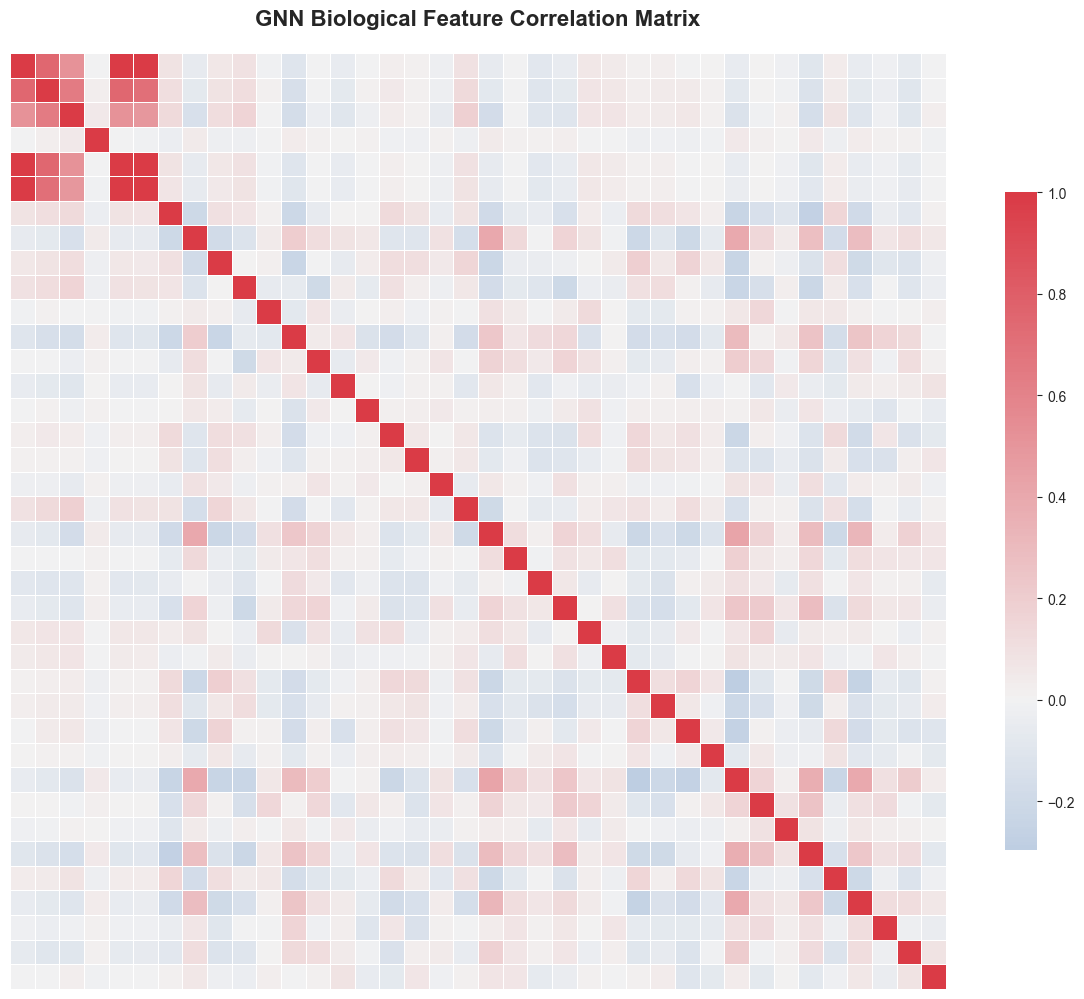

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Generating Feature Correlation Heatmap...")

# Calculate the correlation matrix of your 38 GNN features
corr_matrix = features_df[gnn_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))
sns.set_style("white")

# Draw the heatmap using a divergent colormap (matching the paper's blue-to-red scale)
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(corr_matrix, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, 
            xticklabels=False, yticklabels=False) # Hiding labels because 38 is too crowded

plt.title("GNN Biological Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Model Score Density Distributions

C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\2893262055.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\mutation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


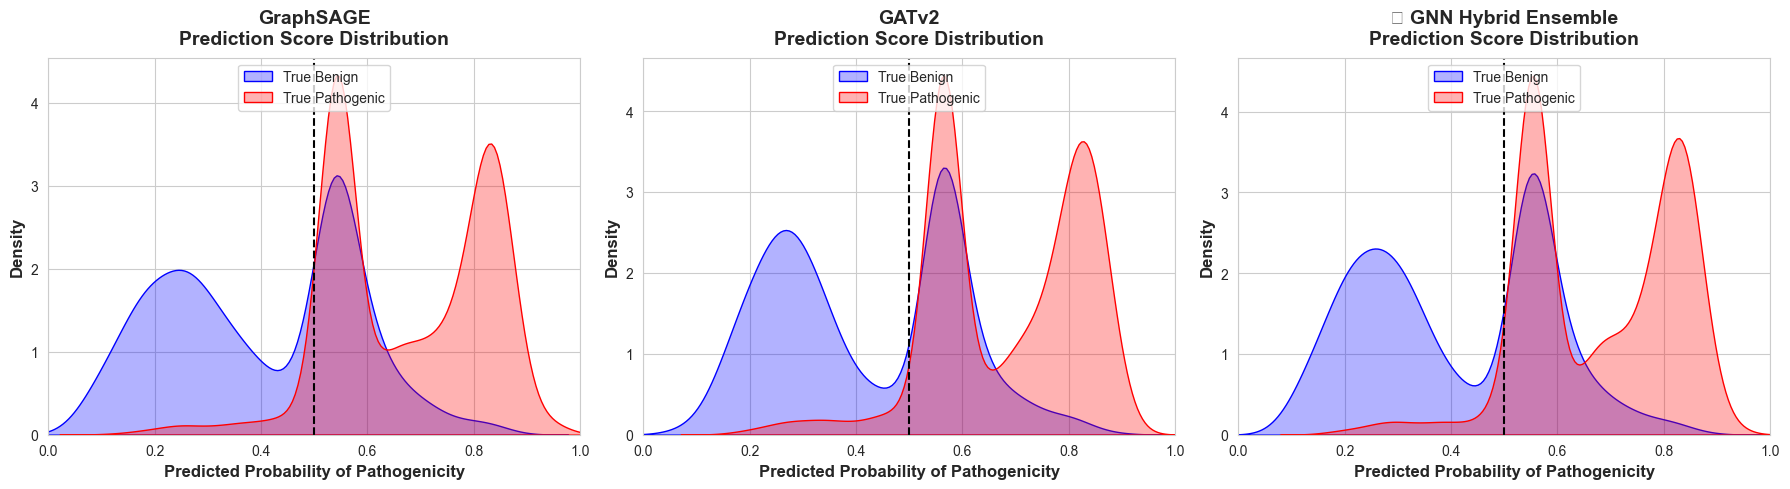

In [15]:
# ==========================================================
# GNN PROBABILITY DENSITY PLOTS (KDE)
# ==========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("GraphSAGE", sage_probs, '#FF9800'),
    ("GATv2", gat_probs, '#F44336'),
    ("★ GNN Hybrid Ensemble", ensemble_probs, '#d32f2f')
]

for i, (name, probs, color) in enumerate(models):
    ax = axes[i]
    
    # Plot distribution for True Benign (Label 0)
    sns.kdeplot(probs[y_test == 0], fill=True, color="blue", alpha=0.3, label="True Benign", ax=ax)
    
    # Plot distribution for True Pathogenic (Label 1)
    sns.kdeplot(probs[y_test == 1], fill=True, color="red", alpha=0.3, label="True Pathogenic", ax=ax)
    
    ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5) # Decision Threshold
    
    ax.set_title(f'{name}\nPrediction Score Distribution', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Probability of Pathogenicity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_xlim([0.0, 1.0])
    ax.legend(loc="upper center", frameon=True)

plt.tight_layout()
plt.show()

Horizontal Bar Charts for AUC and AUPRC

C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\1268963871.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AUC", y="Model", data=bar_data, ax=axes[0], palette=colors)
C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\1268963871.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AUPRC", y="Model", data=bar_data, ax=axes[1], palette=colors)


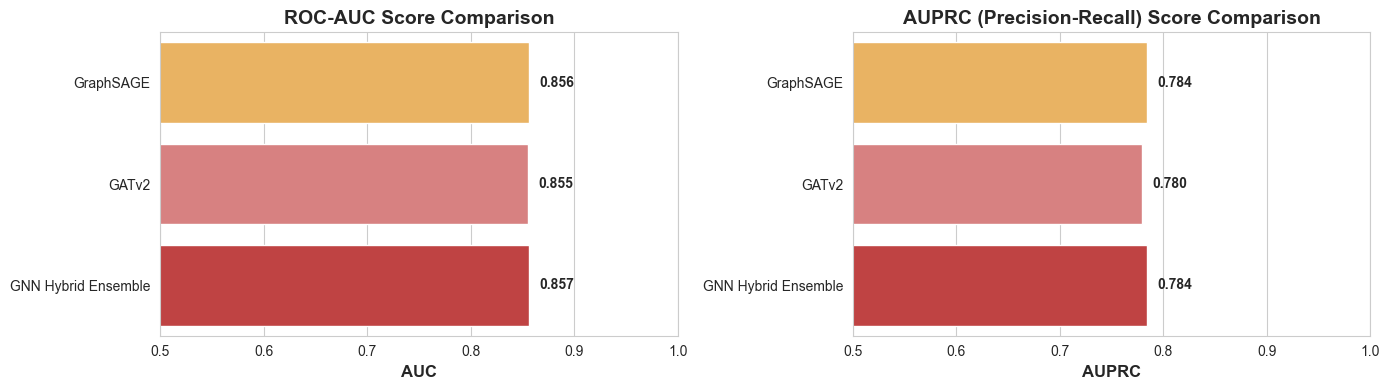

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Calculate metrics
bar_data = {
    "Model": ["GraphSAGE", "GATv2", "GNN Hybrid Ensemble"],
    "AUC": [roc_auc_score(y_test, sage_probs), roc_auc_score(y_test, gat_probs), roc_auc_score(y_test, ensemble_probs)],
    "AUPRC": [average_precision_score(y_test, sage_probs), average_precision_score(y_test, gat_probs), average_precision_score(y_test, ensemble_probs)]
}

# Setup Figure
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#FFB74D', '#E57373', '#d32f2f'] # Light Orange, Light Red, Dark Red

# --- Plot 1: AUC ---
sns.barplot(x="AUC", y="Model", data=bar_data, ax=axes[0], palette=colors)
axes[0].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AUC', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xlim([0.5, 1.0]) # Zoom in to see the differences clearly

# Add text labels on the bars
for i, v in enumerate(bar_data["AUC"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va='center', fontweight='bold')

# --- Plot 2: AUPRC ---
sns.barplot(x="AUPRC", y="Model", data=bar_data, ax=axes[1], palette=colors)
axes[1].set_title('AUPRC (Precision-Recall) Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AUPRC', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlim([0.5, 1.0])

# Add text labels on the bars
for i, v in enumerate(bar_data["AUPRC"]):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

🔬 Running Advanced Graph-Specific Evaluations...
   -> Calculating t-SNE (this might take a few seconds)...


C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\946911025.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=scores, ax=axes[1], palette="viridis")


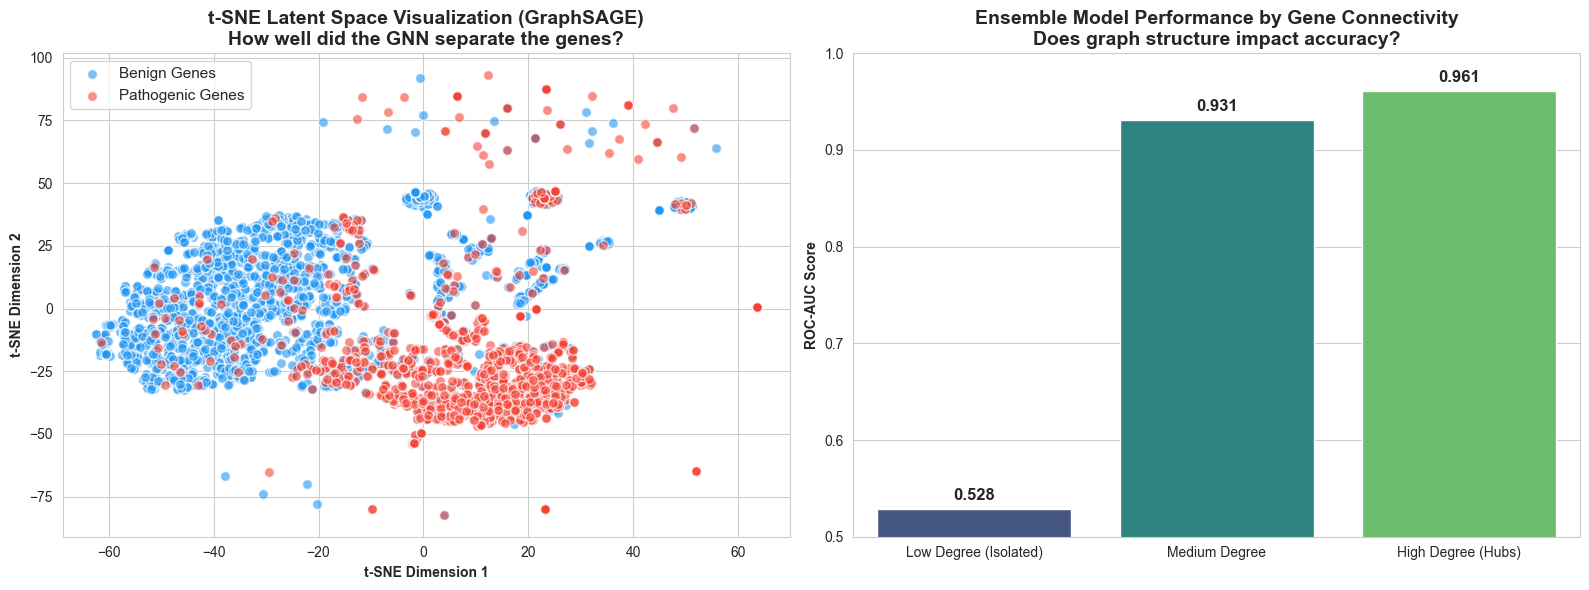

In [18]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score
from torch_geometric.utils import degree

print("🔬 Running Advanced Graph-Specific Evaluations...")

# ==========================================================
# 1. EXTRACT HIDDEN EMBEDDINGS FOR t-SNE
# ==========================================================
# We will extract the hidden layer right before the final classification
def get_hidden_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        x, ei = data.x, data.edge_index
        # Run through first layer and skip connection
        x1 = model.conv1(x, ei) + model.skip(x)
        if hasattr(model, 'ln1'):
            x1 = torch.nn.functional.elu(model.ln1(x1))
        return x1.cpu().numpy()

# Get embeddings specifically for the test set using GraphSAGE
hidden_emb = get_hidden_embeddings(sage_model, graph_data)
test_emb = hidden_emb[test_idx]

print("   -> Calculating t-SNE (this might take a few seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(test_emb)

# ==========================================================
# 2. CALCULATE NODE DEGREES FOR STRATIFICATION
# ==========================================================
# Count how many edges each gene in the test set has
all_degrees = degree(graph_data.edge_index[0], num_nodes=graph_data.x.size(0)).cpu().numpy()
test_degrees = all_degrees[test_idx]

# Bin them into Low, Medium, and High connectivity
bins = np.percentile(test_degrees, [33, 66])
degree_categories = []
for deg in test_degrees:
    if deg <= bins[0]: degree_categories.append("Low Degree (Isolated)")
    elif deg <= bins[1]: degree_categories.append("Medium Degree")
    else: degree_categories.append("High Degree (Hubs)")

df_strat = pd.DataFrame({
    'True_Label': y_test,
    'Ensemble_Prob': ensemble_probs,
    'Degree_Category': degree_categories
})

strat_auc = {}
for cat in ["Low Degree (Isolated)", "Medium Degree", "High Degree (Hubs)"]:
    subset = df_strat[df_strat['Degree_Category'] == cat]
    if len(subset['True_Label'].unique()) > 1: # Ensure we have both classes to calc AUC
        strat_auc[cat] = roc_auc_score(subset['True_Label'], subset['Ensemble_Prob'])
    else:
        strat_auc[cat] = 0.0

# ==========================================================
# 3. PLOT FIGURE 1: t-SNE LATENT SPACE
# ==========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {0: '#2196F3', 1: '#F44336'} # Blue for Benign, Red for Pathogenic
labels = {0: 'Benign Genes', 1: 'Pathogenic Genes'}

for label in [0, 1]:
    idx = (y_test == label)
    axes[0].scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                    c=colors[label], label=labels[label], 
                    alpha=0.6, edgecolors='w', s=50)

axes[0].set_title('t-SNE Latent Space Visualization (GraphSAGE)\nHow well did the GNN separate the genes?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1', fontweight='bold')
axes[0].set_ylabel('t-SNE Dimension 2', fontweight='bold')
axes[0].legend(frameon=True, fontsize=11)

# ==========================================================
# 4. PLOT FIGURE 2: NODE DEGREE STRATIFICATION
# ==========================================================
categories = list(strat_auc.keys())
scores = list(strat_auc.values())

sns.barplot(x=categories, y=scores, ax=axes[1], palette="viridis")
axes[1].set_title('Ensemble Model Performance by Gene Connectivity\nDoes graph structure impact accuracy?', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score', fontweight='bold')
axes[1].set_ylim([0.5, 1.0])

for i, v in enumerate(scores):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

🏥 Calculating Clinical Prioritization Metrics (Cumulative Lift)...


C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\829199552.py:65: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\mutation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


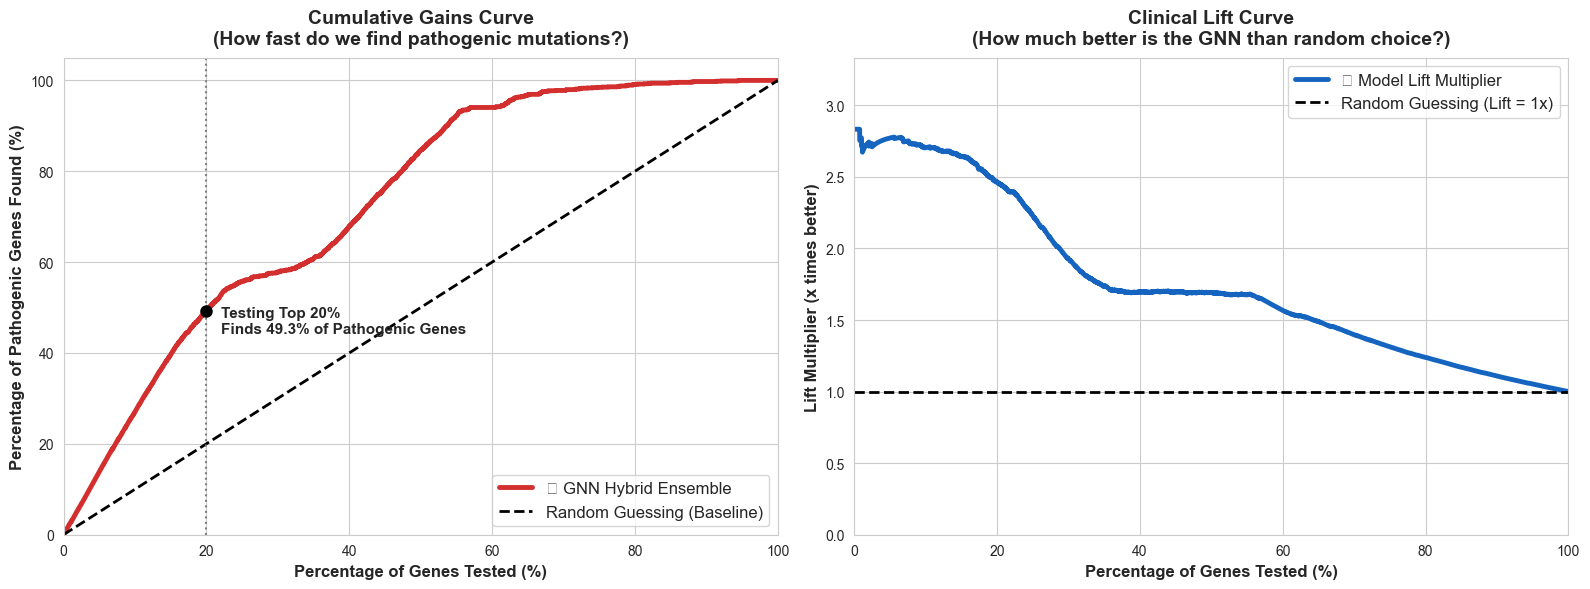

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🏥 Calculating Clinical Prioritization Metrics (Cumulative Lift)...")

# ==========================================================
# 1. CALCULATE GAINS AND LIFT
# ==========================================================
# Sort the true labels based on the Ensemble's predicted probabilities (Highest to Lowest)
sorted_indices = np.argsort(ensemble_probs)[::-1]
y_true_sorted = y_test[sorted_indices]

# Calculate cumulative actual pathogenic genes found
cum_true_positives = np.cumsum(y_true_sorted)
total_pathogenic = np.sum(y_test)

# Calculate percentages of the dataset
dataset_percentages = np.arange(1, len(y_test) + 1) / len(y_test) * 100

# Calculate Cumulative Gains (What % of total pathogenic genes have we found?)
cumulative_gains = (cum_true_positives / total_pathogenic) * 100

# Calculate Lift (How many times better is our model than random guessing?)
# Random guessing would find 10% of pathogenic genes if we checked 10% of the data.
baseline_gains = dataset_percentages
lift = cumulative_gains / baseline_gains

# ==========================================================
# 2. PLOT THE CLINICAL LIFT CURVE
# ==========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT A: Cumulative Gains Curve ---
axes[0].plot(dataset_percentages, cumulative_gains, color='#d32f2f', lw=3.5, label='★ GNN Hybrid Ensemble')
axes[0].plot([0, 100], [0, 100], 'k--', lw=2, label='Random Guessing (Baseline)')

# Draw a line highlighting the Top 20% clinical cutoff
top_20_gain = cumulative_gains[int(len(cumulative_gains)*0.2)]
axes[0].axvline(x=20, color='grey', linestyle=':', lw=1.5)
axes[0].plot(20, top_20_gain, marker='o', markersize=8, color='black')
axes[0].text(22, top_20_gain - 5, f'Testing Top 20%\nFinds {top_20_gain:.1f}% of Pathogenic Genes', fontweight='bold', fontsize=11)

axes[0].set_title('Cumulative Gains Curve\n(How fast do we find pathogenic mutations?)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Percentage of Genes Tested (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage of Pathogenic Genes Found (%)', fontsize=12, fontweight='bold')
axes[0].set_xlim([0, 100])
axes[0].set_ylim([0, 105])
axes[0].legend(loc="lower right", fontsize=12, frameon=True)

# --- PLOT B: Lift Curve ---
axes[1].plot(dataset_percentages, lift, color='#1565C0', lw=3.5, label='★ Model Lift Multiplier')
axes[1].axhline(y=1.0, color='k', linestyle='--', lw=2, label='Random Guessing (Lift = 1x)')

axes[1].set_title('Clinical Lift Curve\n(How much better is the GNN than random choice?)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Percentage of Genes Tested (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Lift Multiplier (x times better)', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 100])
# Set y-limit slightly above the maximum lift to make it look clean
axes[1].set_ylim([0, max(lift) + 0.5]) 
axes[1].legend(loc="upper right", fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

🧬 Running Final Clinical & Statistical Validation Suite...
   -> Running 1,000 Bootstrap iterations (this may take a few seconds)...


C:\Users\aryan\AppData\Local\Temp\ipykernel_18020\110125748.py:128: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\mutation\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


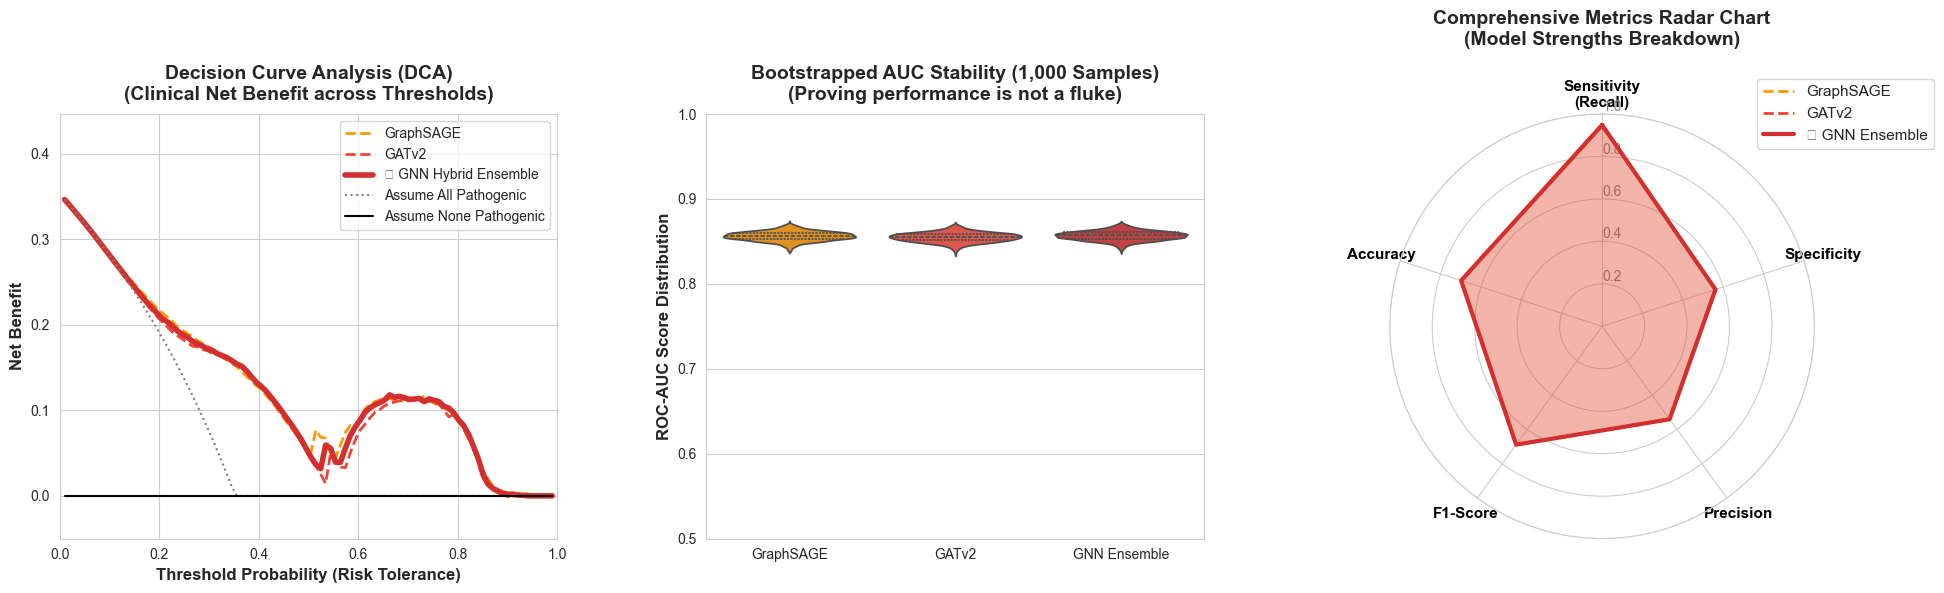

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample
from math import pi

print("🧬 Running Final Clinical & Statistical Validation Suite...")

# ==========================================================
# 1. DECISION CURVE ANALYSIS (DCA)
# ==========================================================
def calculate_net_benefit(y_true, y_probs, thresholds):
    net_benefits = []
    N = len(y_true)
    for pt in thresholds:
        preds = (y_probs >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        # Formula for Net Benefit
        if pt == 1.0: pt = 0.999 # Prevent division by zero
        net_benefit = (tp / N) - (fp / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)
    return np.array(net_benefits)

thresholds = np.linspace(0.01, 0.99, 100)
prevalence = np.sum(y_test) / len(y_test)

# Calculate for baselines and models
nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))
nb_all = np.maximum(nb_all, 0) # Net benefit cannot be less than 0 for "treat all" in this plot context
nb_none = np.zeros_like(thresholds)

nb_sage = calculate_net_benefit(y_test, sage_probs, thresholds)
nb_gat = calculate_net_benefit(y_test, gat_probs, thresholds)
nb_ensemble = calculate_net_benefit(y_test, ensemble_probs, thresholds)

# ==========================================================
# 2. BOOTSTRAPPED CONFIDENCE INTERVALS (1,000 Iterations)
# ==========================================================
print("   -> Running 1,000 Bootstrap iterations (this may take a few seconds)...")
n_iterations = 1000
bootstrap_aucs = {'GraphSAGE': [], 'GATv2': [], 'GNN Ensemble': []}

for i in range(n_iterations):
    # Resample the test set with replacement
    indices = resample(np.arange(len(y_test)), replace=True, random_state=i)
    if len(np.unique(y_test[indices])) < 2: continue # Skip if only one class is sampled
    
    bootstrap_aucs['GraphSAGE'].append(roc_auc_score(y_test[indices], sage_probs[indices]))
    bootstrap_aucs['GATv2'].append(roc_auc_score(y_test[indices], gat_probs[indices]))
    bootstrap_aucs['GNN Ensemble'].append(roc_auc_score(y_test[indices], ensemble_probs[indices]))

boot_df = pd.DataFrame(bootstrap_aucs)

# ==========================================================
# 3. METRICS FOR RADAR CHART
# ==========================================================
def get_radar_metrics(y_true, probs):
    preds = (probs >= 0.5).astype(int) # Standard 0.5 threshold for radar
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn) # Recall
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision+sensitivity) > 0 else 0
    acc = (tp + tn) / len(y_true)
    return [sensitivity, specificity, precision, f1, acc]

categories = ['Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1-Score', 'Accuracy']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the circle

radar_sage = get_radar_metrics(y_test, sage_probs) + [get_radar_metrics(y_test, sage_probs)[0]]
radar_gat = get_radar_metrics(y_test, gat_probs) + [get_radar_metrics(y_test, gat_probs)[0]]
radar_ensemble = get_radar_metrics(y_test, ensemble_probs) + [get_radar_metrics(y_test, ensemble_probs)[0]]

# ==========================================================
# 4. PLOTTING THE 1x3 MASTER RESEARCH SUITE
# ==========================================================
fig = plt.figure(figsize=(20, 6))

# --- PLOT A: Decision Curve Analysis (DCA) ---
ax1 = fig.add_subplot(1, 3, 1)
sns.set_style("whitegrid")
ax1.plot(thresholds, nb_sage, color='#FF9800', lw=2, linestyle='--', label='GraphSAGE')
ax1.plot(thresholds, nb_gat, color='#F44336', lw=2, linestyle='--', label='GATv2')
ax1.plot(thresholds, nb_ensemble, color='#d32f2f', lw=4, label='★ GNN Hybrid Ensemble')
ax1.plot(thresholds, nb_all, color='gray', lw=1.5, linestyle=':', label='Assume All Pathogenic')
ax1.plot(thresholds, nb_none, color='black', lw=1.5, linestyle='-', label='Assume None Pathogenic')

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([-0.05, max(nb_ensemble) + 0.1])
ax1.set_title('Decision Curve Analysis (DCA)\n(Clinical Net Benefit across Thresholds)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Threshold Probability (Risk Tolerance)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Net Benefit', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, frameon=True)

# --- PLOT B: Bootstrapped Violin Plots ---
ax2 = fig.add_subplot(1, 3, 2)
sns.violinplot(data=boot_df, palette=['#FF9800', '#F44336', '#d32f2f'], ax=ax2, inner="quartile")
ax2.set_title('Bootstrapped AUC Stability (1,000 Samples)\n(Proving performance is not a fluke)', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('ROC-AUC Score Distribution', fontsize=12, fontweight='bold')
ax2.set_ylim([0.5, 1.0])

# --- PLOT C: Radar/Spider Chart ---
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.set_theta_offset(pi / 2)
ax3.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')
ax3.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.0)

ax3.plot(angles, radar_sage, color='#FF9800', linewidth=2, linestyle='dashed', label='GraphSAGE')
ax3.fill(angles, radar_sage, color='#FF9800', alpha=0.1)

ax3.plot(angles, radar_gat, color='#F44336', linewidth=2, linestyle='dashed', label='GATv2')
ax3.fill(angles, radar_gat, color='#F44336', alpha=0.1)

ax3.plot(angles, radar_ensemble, color='#d32f2f', linewidth=3, linestyle='solid', label='★ GNN Ensemble')
ax3.fill(angles, radar_ensemble, color='#d32f2f', alpha=0.25)

ax3.set_title('Comprehensive Metrics Radar Chart\n(Model Strengths Breakdown)', fontsize=14, fontweight='bold', pad=25)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()